# Olympiacos FC: Greece vs Europe Performance Analysis

## Objective
Analyze how Olympiacos performs in domestic (Greece) versus European competitions using match-level data.

## Dataset
This dataset includes:
- date
- season
- competition
- opponent
- venue
- goals scored
- goals conceded
- stage
- source

In [12]:
import pandas as pd

df = pd.read_csv("../data/cleaned/olympiacos_matches_clean.csv")
df.head()

,date,season,competition,opponent,venue,goals_for,goals_against,stage,source,competition_type,goal_difference,result,points
0,2023-09-21,2023-2024,Conference League,Freiburg,Home,2,3,Group Stage,UEFA,Europe,-1,Loss,0
1,2023-10-05,2023-2024,Conference League,TSC,Away,3,1,Group Stage,UEFA,Europe,2,Win,3
2,2023-10-26,2023-2024,Conference League,West Ham,Home,2,1,Group Stage,UEFA,Europe,1,Win,3
3,2023-11-09,2023-2024,Conference League,West Ham,Away,0,1,Group Stage,UEFA,Europe,-1,Loss,0
4,2023-11-30,2023-2024,Conference League,Freiburg,Away,0,5,Group Stage,UEFA,Europe,-5,Loss,0


## Greece vs Europe Performance

In this section, we compare how Olympiacos performs in domestic competitions (Greece) versus European competitions.

We look at:
- number of matches
- wins, draws, and losses
- goals scored and conceded
- average points per game

The goal is to see if there is a clear difference in performance between the two.

In [13]:
summary = df.groupby("competition_type").agg(
    matches=("date", "count"),
    wins=("result", lambda x: (x == "Win").sum()),
    draws=("result", lambda x: (x == "Draw").sum()),
    losses=("result", lambda x: (x == "Loss").sum()),
    goals_scored=("goals_for", "sum"),
    goals_conceded=("goals_against", "sum"),
    avg_goals_scored=("goals_for", "mean"),
    avg_goals_conceded=("goals_against", "mean"),
    avg_points=("points", "mean")
).reset_index()

summary["win_rate"] = (summary["wins"] / summary["matches"] * 100).round(2)

summary

,competition_type,matches,wins,draws,losses,goals_scored,goals_conceded,avg_goals_scored,avg_goals_conceded,avg_points,win_rate
0,Europe,15,10,0,5,31,23,2.066667,1.533333,2.000000,66.67
1,Greece,12,8,2,2,32,10,2.666667,0.833333,2.166667,66.67


## What we see so far

- Olympiacos shows a similar level of success in both domestic and European competitions, with an identical win rate of 66.7%.

- The team is more efficient offensively in domestic matches, scoring more goals per game compared to European matches.

- Defensive performance is stronger in Greece, where Olympiacos concedes significantly fewer goals.

- European matches tend to be more decisive, with no draws and more variability in results.

- Despite facing tougher opponents, Olympiacos maintains a high win rate in Europe, which reflects the strength of their Conference League campaign.

## Visual Comparison

To better understand the differences, we visualize key metrics between domestic and European competitions.

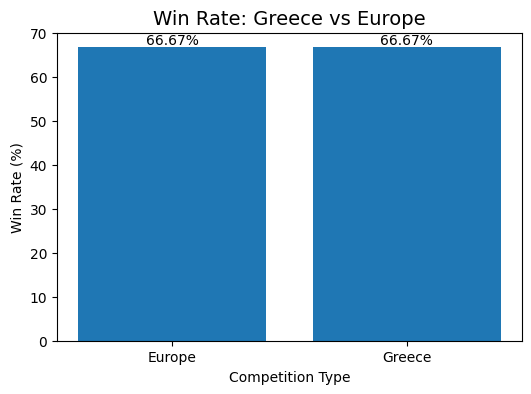

In [14]:
import matplotlib.pyplot as plt

# Bar chart for win rate
plt.figure(figsize=(6,4))

bars = plt.bar(summary["competition_type"], summary["win_rate"])

plt.title("Win Rate: Greece vs Europe", fontsize=14)
plt.xlabel("Competition Type")
plt.ylabel("Win Rate (%)")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height}%", ha='center', va='bottom')

plt.show()

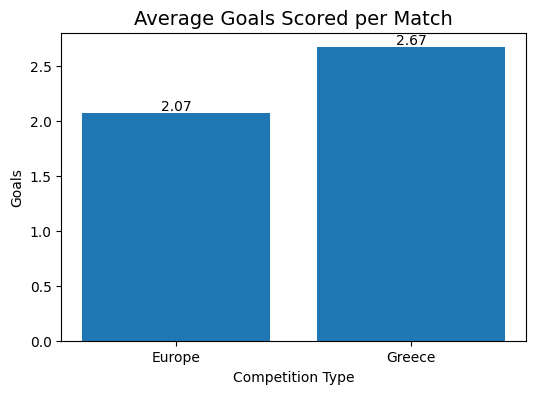

In [15]:
plt.figure(figsize=(6,4))

bars = plt.bar(summary["competition_type"], summary["avg_goals_scored"])

plt.title("Average Goals Scored per Match", fontsize=14)
plt.xlabel("Competition Type")
plt.ylabel("Goals")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             round(height,2), ha='center', va='bottom')

plt.show()

### Goal Scoring

Olympiacos scores more goals on average in domestic matches (2.67 per match) compared to European matches (2.07 per match).

This suggests that the team is more effective offensively in domestic competitions, likely due to facing less defensive pressure than in European matches.

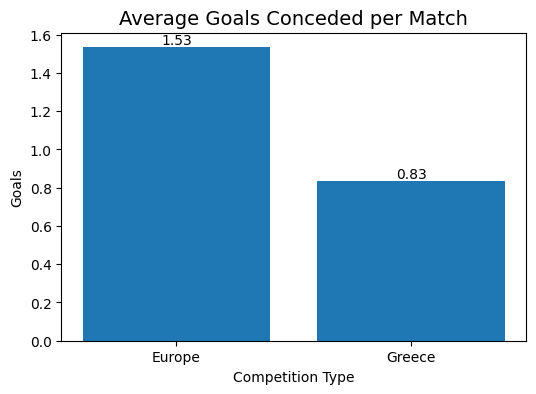

In [16]:
plt.figure(figsize=(6,4))

bars = plt.bar(summary["competition_type"], summary["avg_goals_conceded"])

plt.title("Average Goals Conceded per Match", fontsize=14)
plt.xlabel("Competition Type")
plt.ylabel("Goals")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             round(height,2), ha='center', va='bottom')

plt.show()

### Defensive Performance

Olympiacos concedes significantly more goals in European matches (1.53 per match) compared to domestic matches (0.83 per match).

This indicates that defensive stability is much stronger in Greece, while European matches present greater challenges and higher defensive pressure.

Despite this, the team still maintains a high win rate in Europe, showing strong overall competitiveness.

## Home vs Away Performance

In this section, we analyze whether Olympiacos performs differently when playing at home versus away, and how this differs between Greece and Europe.

In [17]:
home_away = df.groupby(["competition_type", "venue"]).agg(
    matches=("date", "count"),
    wins=("result", lambda x: (x == "Win").sum()),
    goals_scored=("goals_for", "mean"),
    goals_conceded=("goals_against", "mean")
).reset_index()

home_away

,competition_type,venue,matches,wins,goals_scored,goals_conceded
0,Europe,Away,7,3,1.285714,2.000000
1,Europe,Home,7,6,3.000000,1.285714
2,Europe,Neutral,1,1,1.000000,0.000000
3,Greece,Away,6,3,1.833333,0.833333
4,Greece,Home,6,5,3.500000,0.833333


## Home vs Away Insights

- Olympiacos performs significantly better at home in both domestic and European competitions, with higher win rates and more goals scored.

- The difference between home and away performance is much more pronounced in European matches. Away games in Europe show fewer wins, lower scoring, and higher goals conceded.

- In domestic matches, Olympiacos remains relatively stable even when playing away, maintaining solid defensive performance and consistent results.

- European away matches appear to be the most challenging scenario, with the team conceding the highest number of goals and achieving fewer wins.

- Overall, home advantage plays a critical role in European success, while domestic performance is more balanced between home and away matches.

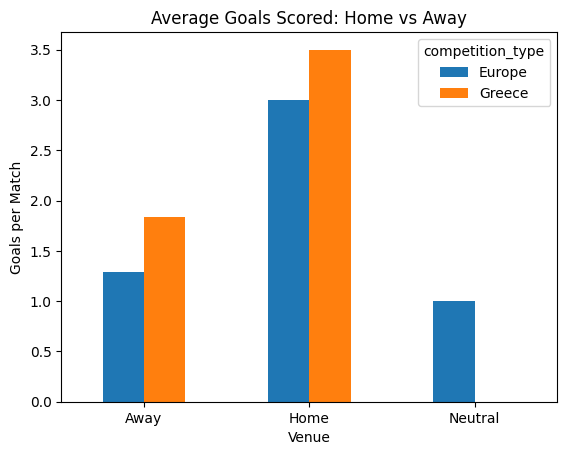

In [18]:
import matplotlib.pyplot as plt

# Pivot data for better plotting
pivot_goals = home_away.pivot(index="venue", columns="competition_type", values="goals_scored")

pivot_goals.plot(kind="bar")

plt.title("Average Goals Scored: Home vs Away")
plt.xlabel("Venue")
plt.ylabel("Goals per Match")

plt.xticks(rotation=0)
plt.show()

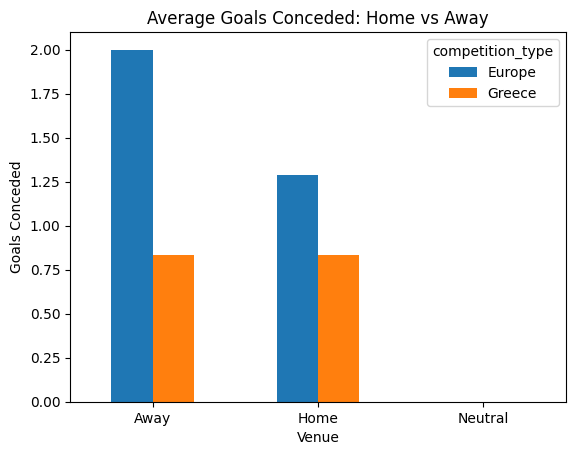

In [19]:
pivot_conceded = home_away.pivot(index="venue", columns="competition_type", values="goals_conceded")

pivot_conceded.plot(kind="bar")

plt.title("Average Goals Conceded: Home vs Away")
plt.xlabel("Venue")
plt.ylabel("Goals Conceded")

plt.xticks(rotation=0)
plt.show()

### Home vs Away Performance

- Olympiacos performs significantly better at home in both domestic and European competitions, scoring more goals and achieving more wins.

- The drop in attacking performance from home to away matches is more noticeable in European competitions, where goals scored decrease significantly.

- Defensive performance remains stable in domestic matches regardless of venue, with consistently low goals conceded.

- In contrast, European away matches show a clear defensive weakness, with the highest number of goals conceded.

- Overall, home advantage plays a much more critical role in European competitions, while domestic performance remains relatively consistent both home and away.

## Key Insights

- Olympiacos is more consistent in domestic matches, with fewer losses and more stable results.

- European matches are more challenging, especially away games, where the team concedes more goals.

- Despite some difficult results in the group stage, Olympiacos significantly improved in the knockout phase.

- The team shows strong performance under pressure, winning important knockout matches against strong opponents.

- Overall, the data shows that while domestic performance is more stable, European success requires adaptability and resilience.

- The transition from group stage inconsistency to knockout stage success highlights the team’s ability to adapt and improve over time.

## Group Stage vs Knockout Performance

In this section, we analyze how Olympiacos performed in the group stage compared to the knockout rounds in the Conference League.

This helps us understand whether the team improved under pressure.

In [20]:
europe_df = df[df["competition_type"] == "Europe"]

stage_analysis = europe_df.groupby("stage").agg(
    matches=("date", "count"),
    wins=("result", lambda x: (x == "Win").sum()),
    goals_scored=("goals_for", "mean"),
    goals_conceded=("goals_against", "mean")
).reset_index()

stage_analysis["win_rate"] = (stage_analysis["wins"] / stage_analysis["matches"] * 100).round(2)

stage_analysis

,stage,matches,wins,goals_scored,goals_conceded,win_rate
0,Final,1,1,1.00,0.000000,100.0
1,Group Stage,6,3,2.00,2.166667,50.0
2,Knockout,4,3,2.25,1.250000,75.0
3,Quarter Final,2,1,1.50,1.500000,50.0
4,Semi Final,2,2,3.00,1.000000,100.0


## Key Match Analysis

We identify the match that could be considered a turning point in Olympiacos' European campaign.

This is typically a game where performance shifts significantly or a strong result is achieved after a difficult period.

In [21]:
europe_df = europe_df.sort_values("date")

europe_df[["date", "opponent", "stage", "goals_for", "goals_against", "result"]]

,date,opponent,stage,goals_for,goals_against,result
0,2023-09-21,Freiburg,Group Stage,2,3,Loss
1,2023-10-05,TSC,Group Stage,3,1,Win
2,2023-10-26,West Ham,Group Stage,2,1,Win
3,2023-11-09,West Ham,Group Stage,0,1,Loss
4,2023-11-30,Freiburg,Group Stage,0,5,Loss
5,2023-12-14,TSC,Group Stage,5,2,Win
6,2024-02-15,Ferencvaros,Knockout,1,0,Win
7,2024-02-22,Ferencvaros,Knockout,1,0,Win
8,2024-03-07,Maccabi Tel Aviv,Knockout,1,4,Loss
9,2024-03-14,Maccabi Tel Aviv,Knockout,6,1,Win


In [22]:
best_match = europe_df.sort_values("goal_difference", ascending=False).head(1)
best_match

,date,season,competition,opponent,venue,goals_for,goals_against,stage,source,competition_type,goal_difference,result,points
9,2024-03-14,2023-2024,Conference League,Maccabi Tel Aviv,Home,6,1,Knockout,UEFA,Europe,5,Win,3


In [23]:
worst_match = europe_df.sort_values("goal_difference").head(1)
worst_match

,date,season,competition,opponent,venue,goals_for,goals_against,stage,source,competition_type,goal_difference,result,points
4,2023-11-30,2023-2024,Conference League,Freiburg,Away,0,5,Group Stage,UEFA,Europe,-5,Loss,0


## Key Match Insight

- The 6–1 victory against Maccabi Tel Aviv stands out as a major turning point in the campaign.

- After losing the first leg 4–1, Olympiacos delivered a dominant performance in the second leg, overturning the deficit in a high-pressure knockout scenario.

- This match highlights the team’s resilience and ability to respond under pressure, which became a defining characteristic of their successful Conference League run.

- Following this result, Olympiacos showed strong performances in subsequent knockout rounds, suggesting a shift in momentum and confidence.

## Group Stage vs Knockout Performance

In this section, we compare Olympiacos' performance in the group stage and knockout rounds of the Conference League.

The goal is to understand whether the team improved as the competition progressed.

In [24]:
europe_df = df[df["competition_type"] == "Europe"]

stage_analysis = europe_df.groupby("stage").agg(
    matches=("date", "count"),
    wins=("result", lambda x: (x == "Win").sum()),
    goals_scored=("goals_for", "mean"),
    goals_conceded=("goals_against", "mean")
).reset_index()

stage_analysis["win_rate"] = (stage_analysis["wins"] / stage_analysis["matches"] * 100).round(2)

stage_analysis

,stage,matches,wins,goals_scored,goals_conceded,win_rate
0,Final,1,1,1.00,0.000000,100.0
1,Group Stage,6,3,2.00,2.166667,50.0
2,Knockout,4,3,2.25,1.250000,75.0
3,Quarter Final,2,1,1.50,1.500000,50.0
4,Semi Final,2,2,3.00,1.000000,100.0


## Group Stage vs Knockout Insights

- Olympiacos shows a clear improvement from the group stage to the knockout rounds.

- In the group stage, the team had a lower win rate (50%) and conceded more goals, indicating inconsistent performance and defensive instability.

- Performance improves significantly in the knockout phase, with a higher win rate (75%) and fewer goals conceded.

- The semi-final stage represents the peak of performance, with a 100% win rate and strong attacking output.

- In the final, Olympiacos adopts a more controlled approach, securing a 1–0 win with solid defensive organization.

- Overall, the data suggests that Olympiacos became more effective and tactically disciplined as the competition progressed.

## Key Match Analysis

In [25]:
europe_df.sort_values("date")[["date","opponent","stage","goals_for","goals_against","result"]]

,date,opponent,stage,goals_for,goals_against,result
0,2023-09-21,Freiburg,Group Stage,2,3,Loss
1,2023-10-05,TSC,Group Stage,3,1,Win
2,2023-10-26,West Ham,Group Stage,2,1,Win
3,2023-11-09,West Ham,Group Stage,0,1,Loss
4,2023-11-30,Freiburg,Group Stage,0,5,Loss
5,2023-12-14,TSC,Group Stage,5,2,Win
6,2024-02-15,Ferencvaros,Knockout,1,0,Win
7,2024-02-22,Ferencvaros,Knockout,1,0,Win
8,2024-03-07,Maccabi Tel Aviv,Knockout,1,4,Loss
9,2024-03-14,Maccabi Tel Aviv,Knockout,6,1,Win


## Key Match Insight

- The 6–1 victory against Maccabi Tel Aviv stands out as the key turning point in Olympiacos' European campaign.

- After losing the first leg 4–1, the team delivered a dominant comeback performance in the second leg, overturning the deficit under high pressure.

- This match highlights Olympiacos' resilience and ability to respond in critical situations.

- Following this result, the team showed strong and consistent performances in the remaining knockout rounds, including victories against Fenerbahce and Aston Villa.

- The comeback win appears to mark a shift in momentum and confidence, which ultimately contributed to winning the Conference League title.

## Final Story

Olympiacos' 2023–2024 Conference League campaign shows a clear progression in performance.

The team started with inconsistent results in the group stage, particularly struggling defensively. However, performance improved significantly in the knockout rounds, with better defensive organization and higher win rates.

A key turning point was the 6–1 victory against Maccabi Tel Aviv, where Olympiacos overturned a heavy first-leg defeat. This match marked a shift in momentum and confidence.

Following this, the team delivered strong performances against high-level opponents such as Fenerbahce and Aston Villa, ultimately winning the final.

Overall, Olympiacos maintained similar success rates domestically and in Europe, but achieved this through different performance patterns — stable and defensively strong in Greece, and more volatile but resilient in Europe.